<a href="https://colab.research.google.com/github/b-paramesh/-Feed_Forward_Neural_Network_for_Car_Price_Prediction/blob/main/Day_30_Forward_Backward_Propagation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Diabetes Risk Prediction (Using TensorFlow FrameWork)

Neural Network Architecture:
2 Inputs-> 3 Hidden Neuron (sigmoid)->1Output(Sigmoid)
Output=1->High Risk Output=0->Low Risk

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


In [ ]:
X=np.array([
    [120,25],
    [85,30],
    [150,35],
    [95,22]
])
X=X/200
Y=np.array([1,0,1,0])
print("Input shape:",X.shape)
print("Output Shape:",Y.shape)


Input shape: (4, 2)
Output Shape: (4,)


In [ ]:
model=Sequential([
    Dense(3,input_shape=(2,),activation="sigmoid"),#Hidden Layer
    Dense(1,activation="sigmoid")#Output Layer
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

#Compile the Model

In [ ]:
model.compile(optimizer="sgd",loss="binary_crossentropy",metrics=["accuracy"])

#Train the model

In [ ]:
model.fit(X,Y,epochs=500,verbose=0)

#Make the Predictions

In [ ]:
predictions=model.predict(X)
print("Predictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predictions:
[[0.5185383 ]
 [0.5144608 ]
 [0.5202767 ]
 [0.51643294]]


Goal:
Predict which flower species an iris belongs to.
Classes:
1 Setosa
2 vericolor
3 virginica


Input layer(4 neurons)
↓
 Hidden Layer (10 neurons,ReLU)
↓
Hidden Layer(5 neurons,ReLU)
↓
Output Layer(3 neurons,Softmax)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax #Convert Probility output -> classIndex
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
#Load the iris Dataset
iris=load_iris()
X=iris.data
y=iris.target
target_names=iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
#Split the dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#Standardize the features
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [ ]:
#Define the model Architecture
model=Sequential()
model.add(Dense(10,activation="relu",input_shape=(X_train.shape[1],)))
model.add(Dense(5,activation="relu"))
model.add(Dense(3,activation="softmax"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history=model.fit(X_train_scaled,y_train,epochs=50,batch_size=4,validation_split=0.1,verbose=1)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3311 - loss: 1.0943 - val_accuracy: 0.0833 - val_loss: 1.1338
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4655 - loss: 0.9040 - val_accuracy: 0.4167 - val_loss: 1.0358
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5284 - loss: 0.9176 - val_accuracy: 0.5833 - val_loss: 0.9592
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6677 - loss: 0.7732 - val_accuracy: 0.5833 - val_loss: 0.8993
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6508 - loss: 0.7152 - val_accuracy: 0.5833 - val_loss: 0.8467
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6449 - loss: 0.7280 - val_accuracy: 0.5833 - val_loss: 0.7874
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6096 - loss: 0.7170 - val_accuracy: 0.5833 - val_loss: 0.7325
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6574 - loss: 0.6285 - val_accuracy: 0.6667 - val_loss

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test_scaled,y_test)
print(f"Test Accuracy:",test_accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9333 - loss: 0.1397
Test Accuracy: 0.9333333373069763


In [ ]:
#make Prediction
y_pred_proba=model.predict(X_test_scaled) #[[0.98 0.01 0.01][0.02 0.94 0.04]]
y_pred=argmax(y_pred_proba,axis=1) #Argmax selects the highest probability. [0.98 0.01 0.01]-> class 0

#Calculate Accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Accuracy: 0.9333333333333333


https://drive.google.com/file/d/1dZNl6pmxv-LruASHWPywaqGcgoDVnZNF/view?usp=sharing
CarPrice_dataset.csv - Google Drive

🚗 AI System for Car Price Prediction
Business Scenario
A used car marketplace company wants to build an AI-based price recommendation system.
Currently, dealers manually estimate the price of cars based on experience. This often leads to:
Incorrect pricing
Loss of potential buyers
Inconsistent valuations
To solve this, the company wants to build an AI model that predicts the price of a car automatically based on its features.

Build a Feed Forward Neural Network model that predicts the price of a car using the provided dataset.
The system should learn relationships between features such as:
Car brand
Fuel type
Engine size
Mileage
Transmission
Other attributes
and predict the expected car price.

CarPrice_dataset.csv
The dataset contains multiple features describing different cars.
Example features may
include:
brand
fuel type
engine size
mileage
transmission
horsepower
number of doors
car body type
Target variable:
Price

 🔹 Task 1 — Data Understanding
Load the dataset and analyze it.
Students must:
Load dataset using pandas
Display first 5 rows
Check dataset information
Check missing values
Show statistical summary

🔹 Task 2 — Data Cleaning
Students must:
Handle missing values
Remove duplicates
Fix inconsistent data types
 🔹 Task 3 — Data Preprocessing
Students must prepare data for neural network.
Required steps:
Encode categorical variables
Example:
Fuel Type → Petrol / Diesel → One Hot Encoding
Transmission → Manual / Automatic
Normalize numerical features
Example:
MinMaxScaler
or
StandardScaler
Split dataset
Train → 80%
Test → 20%
🔹 Task 4 — Build Feed Forward Neural Network
 must design an FNN model.
Architecture example:
Input Layer → Hidden Layer → Hidden Layer → Output Layer
Example configuration:
Input Layer: Number of features
Hidden Layer 1: 64 neurons (ReLU)
Hidden Layer 2: 32 neurons (ReLU)
Output Layer: 1 neuron (Price)
Task 5 — Train the Model
You must train the neural network.
Example configuration:
Loss Function → Mean Squared Error
Optimizer → Adam
Epochs → 50
Batch Size → 32
You must visualize:
Training Loss vs Epochs
🔹 Task 6 — Model Evaluation
Evaluate the model using regression metrics.
Students must compute:
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score
Students must interpret:
Is the model accurate?



🔹 Task 7 — Prediction
 must test the model with new car data.
Example:
Brand: Toyota
Fuel Type: Petrol
Engine Size: 1800
Mileage: 15 km/l
Transmission: Manual
Model should output:
Predicted Price = ₹8,45,000


In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
path="/content/drive/MyDrive/Colab Notebooks/CarPrice_dataset.csv"
df=pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


   car_ID  symboling fueltype aspiration doornumber      carbody drivewheel  \
0       1          3      gas        std        two  convertible        rwd   
1       2          3      gas        std        two  convertible        rwd   
2       3          1      gas        std        two    hatchback        rwd   
3       4          2      gas        std       four        sedan        fwd   
4       5          2      gas        std       four        sedan        4wd   

  enginelocation  wheelbase  carlength  ...  fuelsystem  boreratio  stroke  \
0          front       88.6      168.8  ...        mpfi       3.47    2.68   
1          front       88.6      168.8  ...        mpfi       3.47    2.68   
2          front       94.5      171.2  ...        mpfi       2.68    3.47   
3          front       99.8      176.6  ...        mpfi       3.19    3.40   
4          front       99.4      176.6  ...        mpfi       3.19    3.40   

  compressionratio horsepower  peakrpm citympg  highwaym

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step - loss: 0.7851 - val_loss: 0.8978
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.4256 - val_loss: 0.5615
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2799 - val_loss: 0.3672
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1903 - val_loss: 0.2667
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1609 - val_loss: 0.2206
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1481 - val_loss: 0.1893
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1167 - val_loss: 0.1649
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0908 - val_loss: 0.1544
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0742 - val_loss: 0.1607
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0618 - val_loss: 0.1588
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0526 - val_loss: 0.1480
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0527 - val_loss: 0.1376
Epoch 13/50

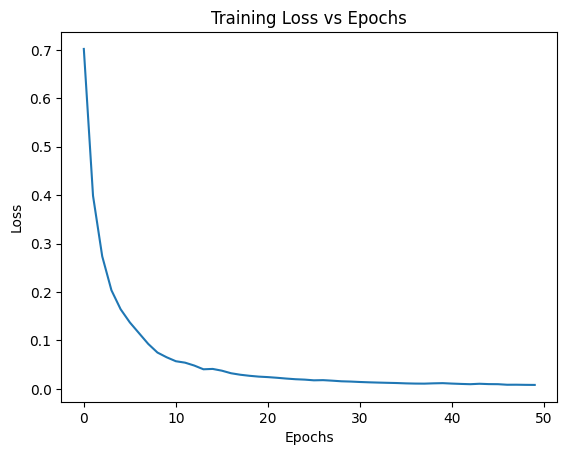

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
MAE: 1389.4443476562499
MSE: 4314805.135376581
RMSE: 2077.2109029601643
R2 Score: 0.945343484062535
Model is accurate
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Predicted Price = ₹ 14098.03


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

df.fillna(df.mean(numeric_only=True), inplace=True)
df.ffill(inplace=True)

df.drop_duplicates(inplace=True)

if 'CarName' in df.columns:
    df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0])
    df.drop('CarName', axis=1, inplace=True)

df['price'] = df['price'].astype(float)

X = df.drop("price", axis=1)
y = df["price"]

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history = model.fit(
    X_train,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

plt.plot(history.history['loss'])
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

pred_scaled = model.predict(X_test)

predictions = y_scaler.inverse_transform(pred_scaled)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

if r2 > 0.8:
    print("Model is accurate")
elif r2 > 0.6:
    print("Model is moderately accurate")
else:
    print("Model needs improvement")

new_car = pd.DataFrame({
    'car_ID':[210],
    'symboling':[1],
    'fueltype':['gas'],
    'aspiration':['std'],
    'doornumber':['four'],
    'carbody':['sedan'],
    'drivewheel':['fwd'],
    'enginelocation':['front'],
    'wheelbase':[102.4],
    'carlength':[175.6],
    'carwidth':[66.5],
    'carheight':[54.9],
    'curbweight':[2200],
    'enginetype':['ohc'],
    'cylindernumber':['four'],
    'enginesize':[180],
    'fuelsystem':['mpfi'],
    'boreratio':[3.3],
    'stroke':[3.4],
    'compressionratio':[9.0],
    'horsepower':[140],
    'peakrpm':[5000],
    'citympg':[15],
    'highwaympg':[20],
    'brand':['toyota']
})

new_car = new_car[X.columns]

new_car_processed = preprocessor.transform(new_car)

pred_scaled = model.predict(new_car_processed)

pred_price = y_scaler.inverse_transform(pred_scaled)

print("Predicted Price = ₹", round(pred_price[0][0],2))